Telecom Customer Churn Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telecom_churn.csv')
print(df.shape)
df.head()

(3333, 11)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


Churn Rate: 14.5%
Retained: 85.5%


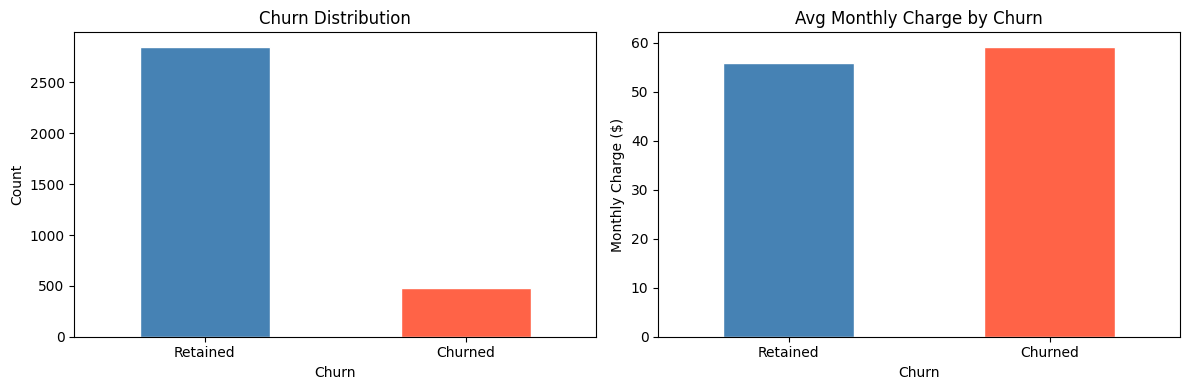

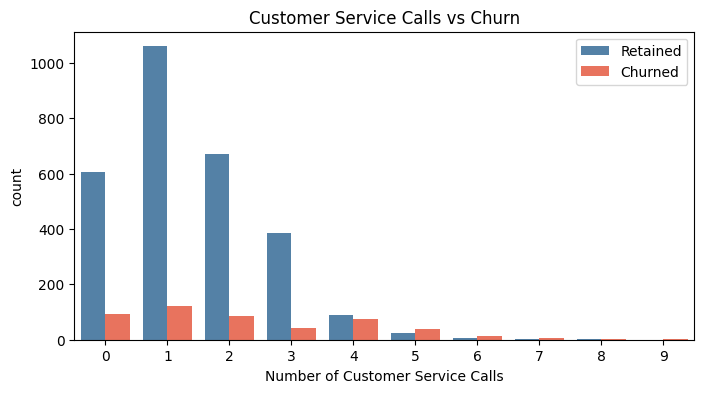

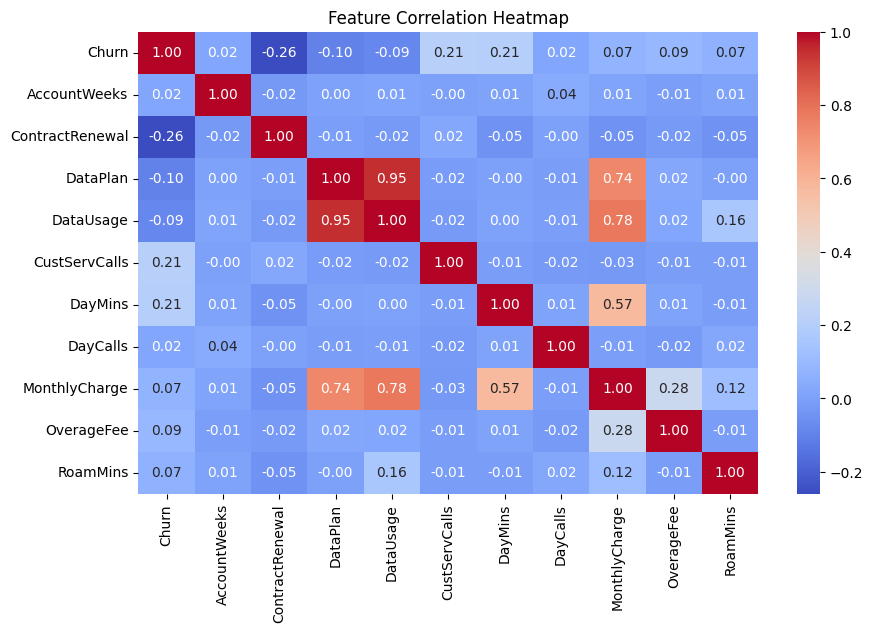

In [2]:
# --- Churn Rate ---
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_rate[1]:.1f}%")
print(f"Retained: {churn_rate[0]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn count
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'],
                                 edgecolor='white')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['Retained', 'Churned'], rotation=0)
axes[0].set_ylabel('Count')

# Monthly charge by churn
df.groupby('Churn')['MonthlyCharge'].mean().plot(kind='bar', ax=axes[1],
                                                   color=['steelblue','tomato'],
                                                   edgecolor='white')
axes[1].set_title('Avg Monthly Charge by Churn')
axes[1].set_xticklabels(['Retained', 'Churned'], rotation=0)
axes[1].set_ylabel('Monthly Charge ($)')
plt.tight_layout()
plt.show()

# --- Customer Service Calls vs Churn ---
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='CustServCalls', hue='Churn', palette=['steelblue','tomato'])
plt.title('Customer Service Calls vs Churn')
plt.xlabel('Number of Customer Service Calls')
plt.legend(['Retained', 'Churned'])
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## EDA Key Findings

- **ContractRenewal** has the strongest negative correlation with churn (-0.26)
  — customers who renew are much less likely to leave
- **CustServCalls** and **DayMins** both positively correlate with churn (0.21)
  — more calls to support = higher churn risk
- **DataPlan and DataUsage** are highly correlated (0.95) — expected
- **DayMins and MonthlyCharge** are correlated (0.57) — more usage = higher bill
- Churn spikes noticeably at 4+ customer service calls

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Logistic Regression ---
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# --- Compare ---
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.3f}")

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.62      0.18      0.28       101

    accuracy                           0.86       667
   macro avg       0.75      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667

ROC-AUC: 0.831

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       566
           1       0.86      0.61      0.72       101

    accuracy                           0.93       667
   macro avg       0.90      0.80      0.84       667
weighted avg       0.92      0.93      0.92       667

ROC-AUC: 0.921


## Model Results

| Metric       | Logistic Regression | Random Forest |
|--------------|-------------------|---------------|
| Accuracy     | 86%               | 93%           |
| ROC-AUC      | 0.831             | 0.921         |
| Churn Recall | 0.18              | 0.61          |
| Churn F1     | 0.28              | 0.72          |

**Random Forest is the stronger model across all metrics.**

- Logistic Regression misses 82% of actual churners (recall 0.18) — too risky for business use
- Random Forest catches 61% of churners with 86% precision — much more actionable
- ROC-AUC of 0.921 means the model has strong ability to distinguish churners from retained customers

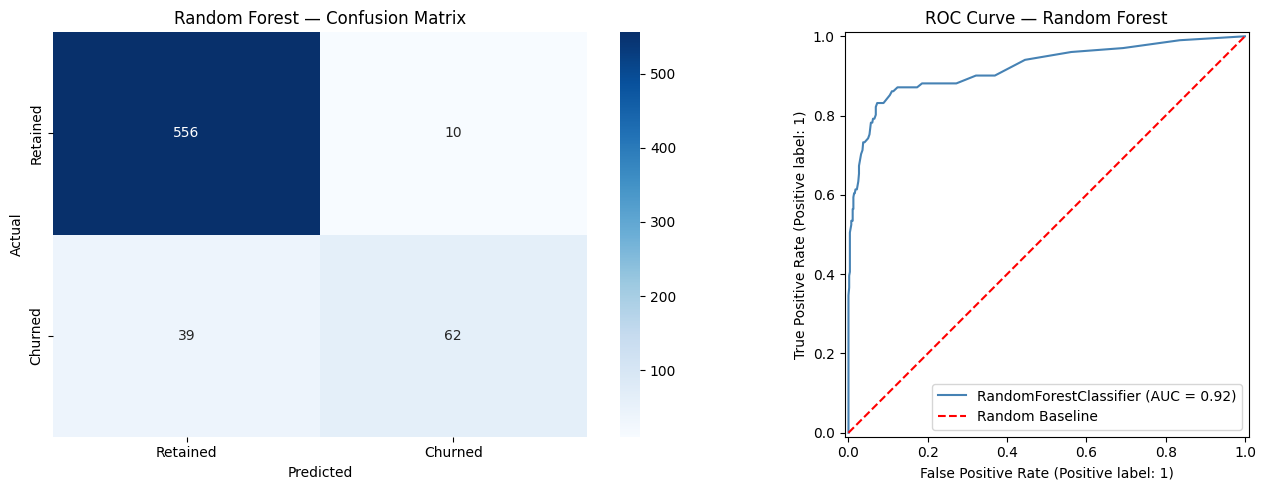

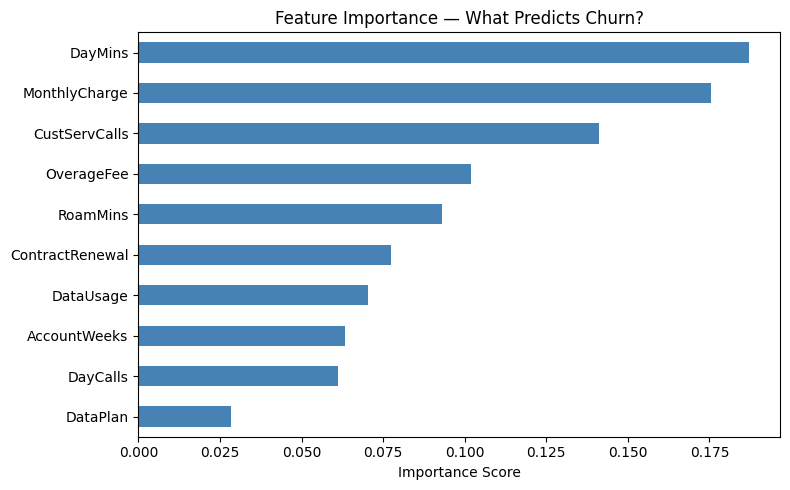

In [4]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], color='steelblue')
axes[1].plot([0,1],[0,1],'r--', label='Random Baseline')
axes[1].set_title('ROC Curve — Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance — What Predicts Churn?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Conclusions & Key Findings

### What predicts customer churn?
- **DayMins** and **MonthlyCharge** are the top predictors — high usage customers churn more
- **CustServCalls** is 3rd most important — frequent support calls are a strong churn signal
- **ContractRenewal** negatively correlates with churn — renewing customers tend to stay

### Model Performance Summary
- Random Forest (AUC 0.92) significantly outperforms Logistic Regression (AUC 0.83)
- Confusion matrix shows 556 correct retentions and 62 correct churn predictions
- Only 39 churners missed (false negatives) — strong real-world performance

### Business Insight
Telecom companies should prioritize customers with high monthly charges,
frequent service calls, and no contract renewal as highest churn risk.

### Next Steps
- Try XGBoost for potentially higher accuracy
- Address class imbalance with SMOTE oversampling
- Build a churn risk scoring system per customer